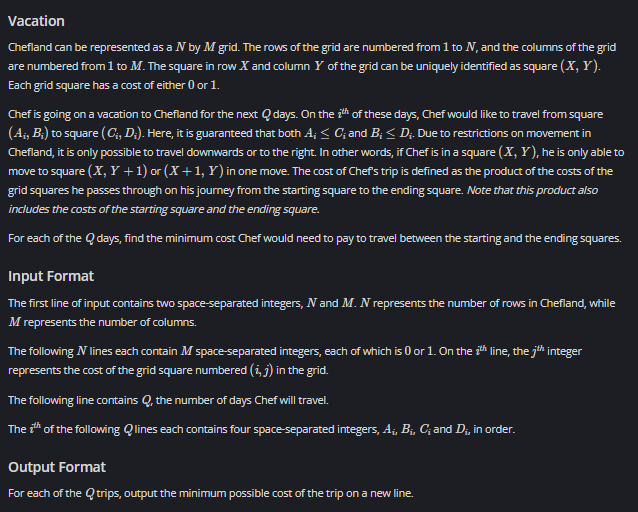
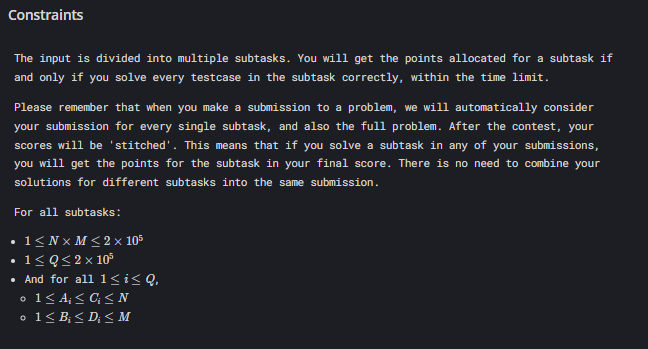
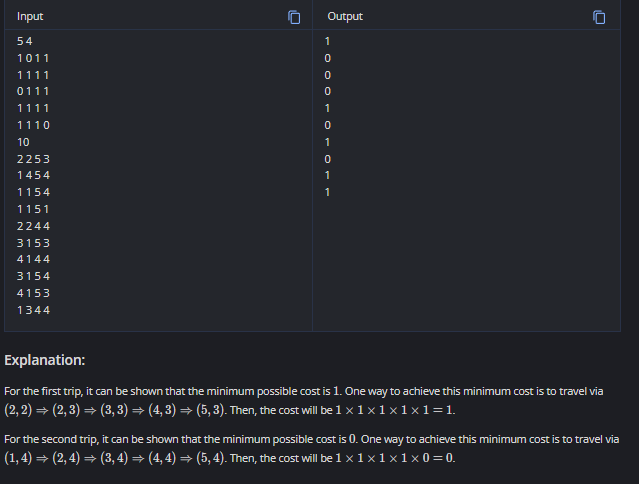

In [ ]:

# Read grid dimensions
n, m = map(int, input().split())

# Read the grid
mat = []
for i in range(n):
    mat.append(list(map(int, input().split())))

# Build prefix sum array ONCE (before queries)
# PSum[i][j] = count of 0-cost cells in rectangle from (0,0) to (i,j)
PSum = [[0] * m for _ in range(n)]

# PSum[i][j] = PSum[i-1][j] + PSum[i][j-1] - PSum[i-1][j-1] + mat[i][j]
for i in range(n):
    for j in range(m):
        # Count 1 if cell cost is 0, else 0
        # converting the forest where 1 -> 0, where 0 -> 1 and simultaneously building the prefix sum
        curr = 1 if mat[i][j] == 0 else 0
        
        left = PSum[i-1][j] if i > 0 else 0
        top = PSum[i][j-1] if j > 0 else 0
        diag = PSum[i-1][j-1] if i > 0 and j > 0 else 0
        
        PSum[i][j] = left + top - diag + curr

# Process queries
q = int(input())
for _ in range(q):
    a, b, c, d = map(int, input().split())
    
    # Convert to 0-indexed
    x1, y1 = a - 1, b - 1
    x2, y2 = c - 1, d - 1
    
    # Calculate count of 0-cost cells in rectangle (x1,y1) to (x2,y2)
    # prefixSum = PSum[x2][y2] - PSum[x1 - 1][y2] - PSum[x2][y1 - 1] + PSum[x1 - 1][y1 - 1]
    count_zeros = PSum[x2][y2]
    count_zeros -= PSum[x1-1][y2] if x1 > 0 else 0
    count_zeros -= PSum[x2][y1-1] if y1 > 0 else 0
    count_zeros += PSum[x1-1][y1-1] if x1 > 0 and y1 > 0 else 0
    
    # If any 0-cost cell exists in path, product = 0, else product = 1
    if count_zeros > 0:
        print(0)
    else:
        print(1)
          
    
# Input Example:

# 5 4
# 1 0 1 1
# 1 1 1 1
# 0 1 1 1
# 1 1 1 1
# 1 1 1 0
# 10
# 2 2 5 3
# 1 4 5 4
# 1 1 5 4
# 1 1 5 1
# 2 2 4 4
# 3 1 5 3
# 4 1 4 4
# 3 1 5 4
# 4 1 5 3
# 1 3 4 4

KeyboardInterrupt: Interrupted by user

Given an array of N elments, answer the following Q querries 
Querry : [L,R]
Result : A[L] + 2 * A[L + 1] + 3 * A[L + 2] + 4 * A[L + 3] + ...... + [R - L + 1] * A[R]

In [2]:
# BRUTE FORCE 

q = int(input())
# print(q)
n =int(input())
# print(n)
arr = []
arr = list(map(int, input().split()))
# print(arr)
while q > 0:
    l, r = map(int, input().split())
    print(l, r)
    sum = 0
    j = 1
    for i in range(l - 1, r):
        sum += j*arr[i]
        j += 1
        # print(sum)
    q -= 1
    print(sum)


# SAMPLE INPUT:
# 4
# 6
# 2 4 3 6 9 1
# 2 3
# 2 5
# 1 3
# 4 6


2 3
10
2 5
64
1 3
19
4 6
27


In [ ]:
# OPTIMAL SOLUTION - USING PREFIX SUM

# Number of queries
q = int(input())
# print(q)

# number of elements in the array
n =int(input())
# print(n)

# Taking input for the array
arr = []
arr = list(map(int, input().split()))
print(arr)

# Computing the i * A[i]
mul = [0] * n
mul[0] = arr[0]

for i in range(1, n):
    mul[i] = (i + 1) * arr[i]
print(mul)

# Computing prefix sum for i * A[i] (val1)
pre_mul = [0] * n
pre_mul[0] = mul[0]

for i in range(1, n):
    pre_mul[i] = pre_mul[i - 1] + mul[i]
print(pre_mul)

# Computing the presum of arr (val2)
PSum = [0] * n
PSum[0] = arr[0]
for i in range(1, n):
    PSum[i] = PSum[i - 1] + arr[i]
print(PSum)


# print(arr)
while q > 0:
    a, b = map(int, input().split())
    l = a - 1 
    r = b - 1  
    # print(l, r)
    if l > 0:
        val1 = pre_mul[r] - pre_mul[l - 1] 
        val2 = (l) * (PSum[r] - PSum[l - 1])
        ans = val1 - val2
    else:
        ans = pre_mul[r]
    
    print(ans)
    q -= 1

# SAMPLE INPUT:
# 4
# 6
# 2 4 3 6 9 1
# 2 3
# 2 5
# 1 3
# 4 6



ValueError: invalid literal for int() with base 10: ''

HW QUESTION
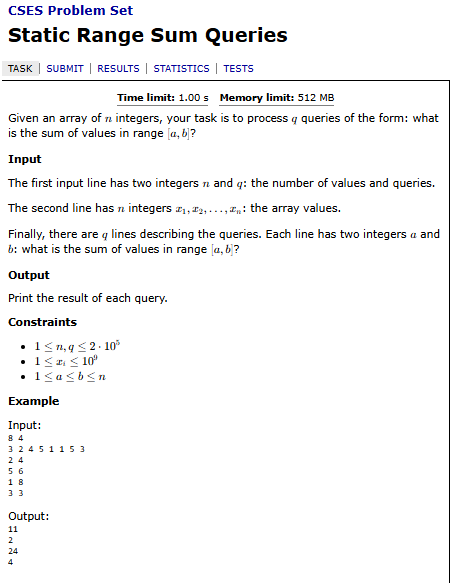

In [ ]:

n, q = map(int, input().split())
# print(n, q)

arr = list(map(int, input().split()))
# print(arr)

presum = [0] * n
presum[0] = arr[0]
for i in range(n):
    presum[i] = presum[i - 1] + arr[i]
# print(presum)

for i in range(q):
    a, b = map(int, input().split())
    x = a - 1
    y = b - 1
    
    if x > 0:
        print(presum[y] - presum[x - 1])
    else:
        print(presum[y])
    
    q-=1

Given an array with all the values as initially zero.

perform the following 'Q' querries on it:
'i-th' query you will be given 3 intgers Li,Ri,Xi 

you need to add Xi to all the values in the array from Li to Ri 
After performing all the queries print the array 

In [ ]:
# BRUTE FORCE - ITERATE OVER THE QUERY FROM L TO R AND X EACH TIME

def cal(arr, l, r, x):
    
    # n = len(arr)
    
    for i in range(l,r+1):
        arr[i] += x
    
    return arr
        

q = int(input())
# print(q)
n =int(input())
# print(n)
arr = [0] * n

while q > 0:
    a, b, x = map(int, input().split())
    l = a - 1
    r = b - 1
    
    arr = cal(arr, l, r, x)
    q -= 1
    
print(arr)


# SAMPLE INPUT:
# 3 - number of qurries
# 6 - number of elements in the array
# qurries:
# 1 2 3 
# 2 3 2
# 3 5 1

In [ ]:
# OPTIMAL SOLUTION -USING DIFF ARRAY

q = int(input())
# print(q)
n =int(input())
# print(n)
arr = [0] * n


# print(arr)
while q > 0:
    a, b, x = map(int, input().split())
    l = a - 1 
    r = b - 1  
    # print(l, r)
    
    arr[l] += x
    if r + 1 < n:
        arr[r + 1] -= x
    
    # print(arr)
    q -= 1

PSum = [0] * n
PSum[0] = arr[0]
for i in range(1, n):
    PSum[i] = PSum[i - 1] + arr[i]
    
    
print(PSum)

HOME WORK

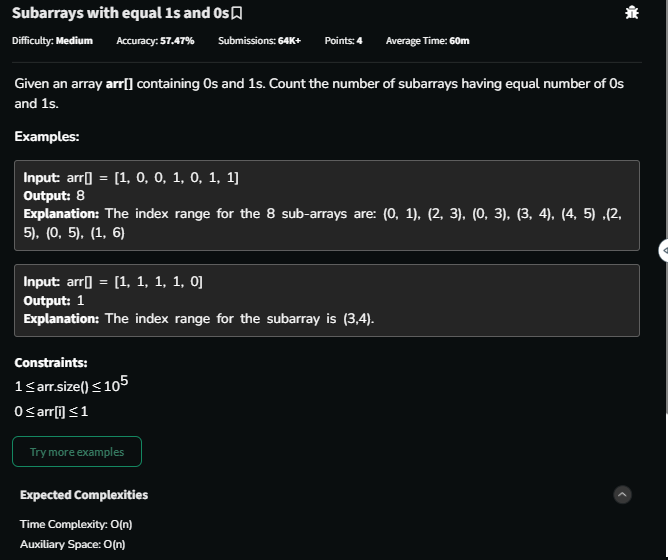

Dry Run (Tabular Format)

Input: arr = [1, 0, 0, 1, 0, 1, 1] Logic:

0 → subtract 1 from pref.

1 → add 1 to pref.

ans += freq[pref]: Add the number of times this specific pref has been seen before (each previous occurrence marks a valid subarray ending here).

freq[pref] += 1: Update the count for this pref.
Initial State: pref = 0, freq = {0: 1}, ans = 0

| Index | Value (`x`) | Transformation | New `pref` | `freq` before update | Contribution to `ans` (`freq[pref]`) | Valid Subarrays Identified (End at current index) | Update `freq` |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **0** | `1` | +1 | **1** | `{0: 1}` | `freq[1]` = **0** | None | `freq[1] = 1` |
| **1** | `0` | -1 | **0** | `{0: 1, 1: 1}` | `freq[0]` = **1** | `[1, 0]` (Indices 0 to 1) | `freq[0] = 2` |
| **2** | `0` | -1 | **-1** | `{0: 2, 1: 1}` | `freq[-1]` = **0** | None | `freq[-1] = 1` |
| **3** | `1` | +1 | **0** | `{0: 2, 1: 1, -1: 1}` | `freq[0]` = **2** | `[0, 1]` (Indices 2 to 3)<br>`[1, 0, 0, 1]` (Indices 0 to 3) | `freq[0] = 3` |
| **4** | `0` | -1 | **-1** | `{0: 3, 1: 1, -1: 1}` | `freq[-1]` = **1** | `[0]` (Indices 3 to 4) → *Wait, value is 0, so subarray is `[1, 0]` from indices 3 to 4* | `freq[-1] = 2` |
| **5** | `1` | +1 | **0** | `{0: 3, 1: 1, -1: 2}` | `freq[0]` = **3** | `[0, 1]` (Indices 4 to 5)<br>`[0, 1, 0, 1]` (Indices 2 to 5)<br>`[1, 0, 0, 1, 0, 1]` (Indices 0 to 5) | `freq[0] = 4` |
| **6** | `1` | +1 | **1** | `{0: 4, 1: 1, -1: 2}` | `freq[1]` = **1** | `[0, 1, 1]`? No. The subarray is from after the previous `pref=1` (index 0) to now. So indices 1 to 6: `[0, 0, 1, 0, 1, 1]` | `freq[1] = 2` |

Total ans = 0 + 1 + 0 + 2 + 1 + 3 + 1 = 8.

In [ ]:
from collections import defaultdict
class Solution:
    def countSubarray(self, arr):

        pref = 0

        freq = defaultdict(int)
        # print(freq)

        freq[0] = 1 
        # print(freq)

        ans = 0

        for x in arr:

            if x == 0:
                pref = pref - 1
            else:
                pref = pref + 1

            ans += freq[pref]

            freq[pref] += 1
        # print(pref)
        # print(freq)

        return ans
        


HOME WORK - 3

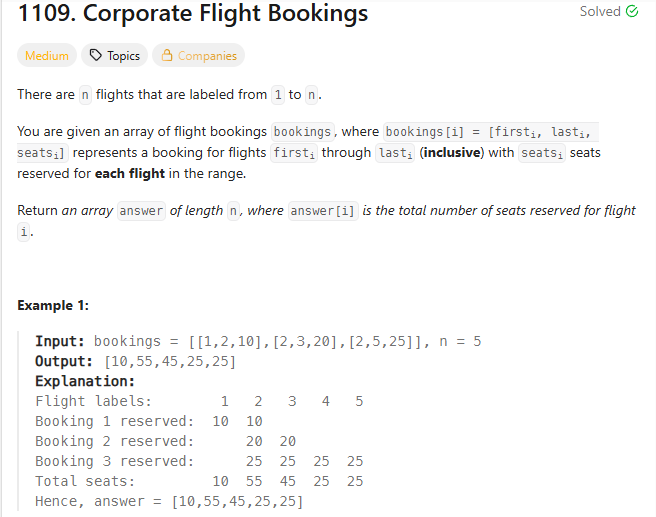

In [ ]:
class Solution(object):
    def corpFlightBookings(self, bookings, n):
        """
        :type bookings: List[List[int]]
        :type n: int
        :rtype: List[int]
        """
        m = len(bookings)

        arr = [0] * n

        for i in range(m):
            
            l = bookings[i][0]
            r = bookings[i][1]
            seats = bookings[i][2]

            l -= 1
            r -= 1
            # print(l, r, seats)
            arr[l] += seats
            if r + 1 < n:
                arr[r + 1] -= seats
            # print(arr)
        # print(arr)


        presum = [0] * n
        presum[0] = arr[0]
        if n == 1:
            return presum
        else:
            for i in range(n):
                presum[i] = presum[i - 1] + arr[i]
        # print(presum)
        
        return presum
        
soln = Solution()
print(soln.corpFlightBookings([[1,2,10],[2,2,15]], 2))


        